<strong>Import Libraries</strong>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

<strong>Load and Inspect the Dataset</stong>

In [2]:
df = pd.read_csv("D:\Projects\Python_projects\Machine_Learning\CodeAlpha\Car Price Prediction with Machine Learning\car data.csv")
print('head',df.head())
print('Summary',df.describe())
print("Missing values",df.info())


head   Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
Summary               Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.1

<strong>Data Preprocessing & Feature Engineering</strong>

In [3]:
# Feature Engineering: Calculate car age
current_year = 2026
df['Car_Age'] = current_year - df['Year']

# Drop original 'Year' and 'Car_Name' (name has too many unique values for a basic model)
df = df.drop(['Year', 'Car_Name'], axis=1)

# Convert categorical variables using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

display(df.head())

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


<strong>Exploratory Data Analysis (EDA)</strong>

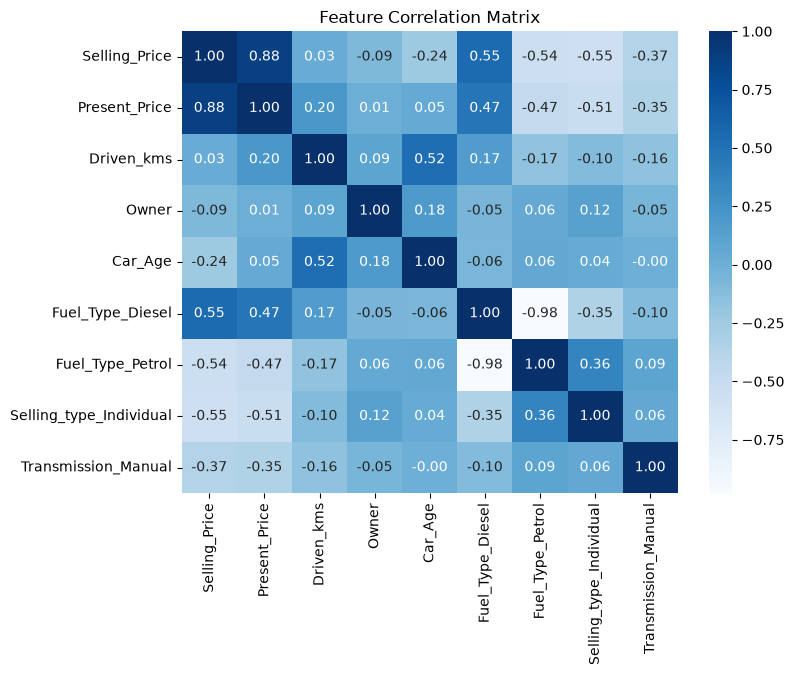

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()



<strong>Overview of the Heatmap</strong>
Purpose: This heatmap visualizes the Pearson correlation coefficients ($r$) between all numerical and one-hot encoded variables in the dataset.<br>
Scale: Values range from -1.0 (perfect negative correlation) to +1.0 (perfect positive correlation). Darker blue indicates stronger positive correlations, while lighter shades indicate weaker or negative relationships.<br>
Present_Price ($r = 0.88$): Shows a very strong positive correlation. This is the single most important predictor—cars with a higher original showroom price command much higher resale values.<br>
Fuel_Type_Diesel ($r = 0.55$): Shows a moderate positive correlation. Diesel cars generally hold higher resale values compared to other fuel <br>
types.Selling_type_Individual ($r = -0.55$) & Transmission_Manual ($r = -0.37$): Show negative correlations. Cars sold by individual private owners rather than formal dealers, or cars with manual transmissions instead of automatics, tend to have lower selling prices on average.<br>
Car_Age ($r = -0.24$): Shows a negative correlation, meaning older cars lose value over time due to depreciation.<br>
Driven_kms ($r = 0.03$): Shows a negligible direct linear correlation with price when viewed independently, though it heavily impacts car age and condition.

<strong>Train the Regression Model</strong>

In [5]:
# Define features (X) and target (y)
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


<strong>Model Evaluation & Business Insights</strong>

In [6]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# Feature Importance
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)
print("\nTop Feature Importances:")
print(importance)

R-squared Score: 0.9585
RMSE: 0.9774

Top Feature Importances:
                   Feature  Importance
0            Present_Price    0.879515
3                  Car_Age    0.061085
1               Driven_kms    0.040046
7      Transmission_Manual    0.009704
5         Fuel_Type_Petrol    0.003450
4         Fuel_Type_Diesel    0.003398
6  Selling_type_Individual    0.002316
2                    Owner    0.000486


<strong>Overall Model Performance</strong><br>
R-squared Score (0.9585 / ~95.85%):
This is an outstanding score. It indicates that nearly 96% of the variance in used car selling prices is successfully explained by your model's features.<br>

Root Mean Squared Error (RMSE: 0.9774):<br>

On average, your model's price predictions deviate from actual market prices by less than 1 unit (roughly 1,000 currency units depending on your dataset's currency scale), signifying high precision.<br>

Present_Price (0.8795 / ~88%):<br>

By far the dominant predictor in the dataset. A car's original showroom/present price sets the primary baseline for its current market value, accounting for almost 88% of the model's predictive weight.<br>

Car_Age (0.0611 / ~6.1%):<br>

The second most impactful factor. Depreciation over time heavily dictates how much value a car loses from its original price.<br>

Driven_kms (0.0400 / ~4%):<br>

Total mileage provides a secondary indicator of vehicle wear-and-tear, heavily correlating with how much a car has depreciated.

Minor Factors (Transmission_Manual, Fuel_Type, Selling_type, Owner):<br>

Together, these categorical features account for the remaining ~2% of importance. While they refine the prediction (e.g., distinguishing between manual/automatic or diesel/petrol), the core financial valuation is overwhelmingly driven by the original price and vehicle age.